In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
np.random.seed(42)

In [2]:
df = pd.read_csv(r'C:\Users\Usuario\Downloads\DATASET_SVR.csv')

In [3]:
df.head(5)

,feature,target
0,0.000000,0.149014
1,0.033445,0.042036
2,0.066890,0.360760
3,0.100334,0.705153
4,0.133779,0.258090


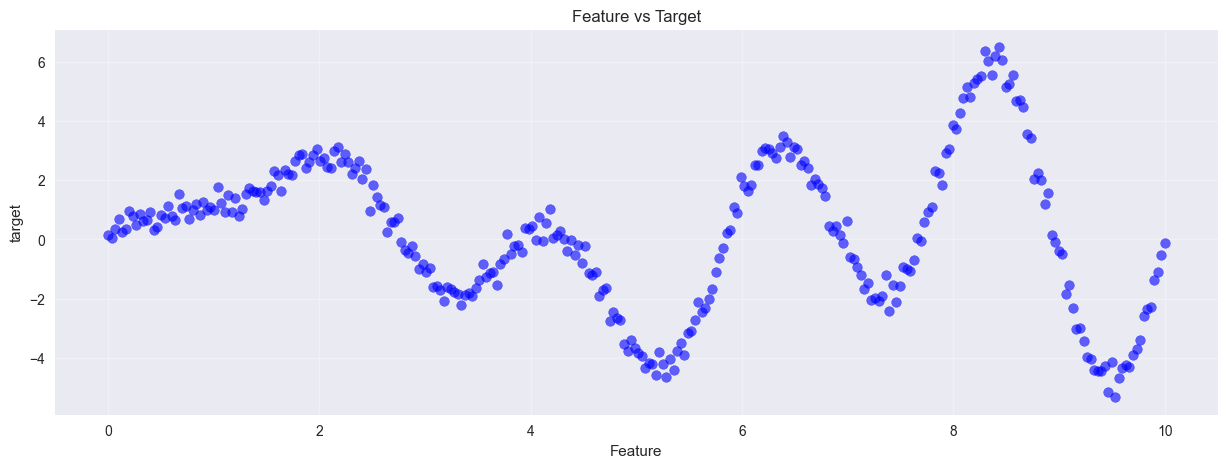

In [4]:
# Grafico de feature vs variable de target
plt.figure(figsize = (15,5))

plt.scatter(df['feature'], df['target'], alpha = 0.6, color = 'blue')
plt.xlabel('Feature')
plt.ylabel('target')
plt.title('Feature vs Target')
plt.grid(True, alpha = 0.3)
plt.show()

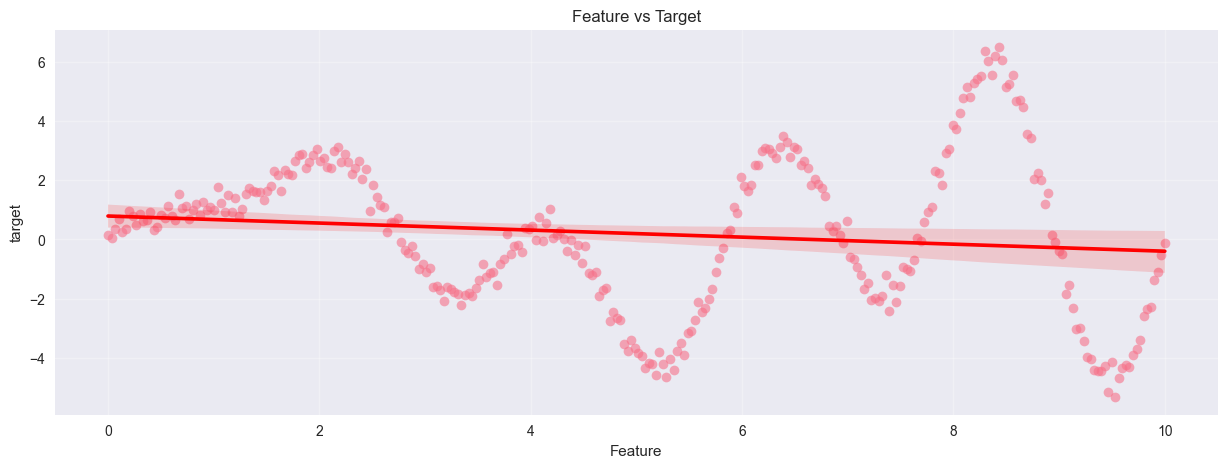

In [5]:
plt.figure(figsize = (15,5))

sns.regplot(x = 'feature', y = 'target', data = df,
            scatter_kws = {'alpha': 0.6}, line_kws = {'color': 'red'})
plt.xlabel('Feature')
plt.ylabel('target')
plt.title('Feature vs Target')
plt.grid(True, alpha = 0.3)
plt.show()

# Modelo

In [6]:
# Definición de variables independientes y target
X = df[['feature']]

y = df[['target']] 

# Separacion en entreno y prueba del modelo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [7]:
# Modelo SVR con kernel gausiano
# Definición de pipeline con scaler y SVR model
svr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR(kernel = 'rbf'))
])

# Definición del grid de parametros donde el modelo va a testear
param_grid_rbf = {
    'svr__C': [0.1, 1, 10, 100],
    'svr__epsilon': [0.01, 0.1, 0.5],
    'svr__gamma': ['auto']
}

# Uso del modelo definido en pipeline con los parametros definidos
grid_search_rbf = GridSearchCV(
    svr_pipeline,
    param_grid_rbf,
    scoring = 'r2'
)

# Ajustar con nuestros datos
grid_search_rbf.fit(X_train, y_train)

best_params_rbf = grid_search_rbf.best_params_
svr_rbf_best = grid_search_rbf.best_estimator_
y_pred_rbf = svr_rbf_best.predict(X_test)

r2_rbf =r2_score(y_test, y_pred_rbf)
mse_rbf = mean_squared_error(y_test, y_pred_rbf)
mae_rbf = mean_absolute_error(y_test, y_pred_rbf)

In [ ]:
# Modelo SVR con kernel poly
# Definición de pipeline con scaler y SVR model
svr_poly_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR(kernel = 'poly'))
])

# Definición del grid de parametros donde el modelo va a testear
param_grid_poly = {
    'svr__C': [0.1, 1, 10, 100],
    'svr__epsilon': [0.01, 0.1, 0.5],
    'svr__gamma': ['auto'],
    'svr__degree': [2,3,4,5,6,7,8,9,10]
}

# Uso del modelo definido en pipeline con los parametros definidos
grid_search_poly = GridSearchCV(
    svr_poly_pipeline,
    param_grid_poly,
    scoring = 'r2'
)

# Ajustar con nuestros datos
grid_search_poly.fit(X_train, y_train)

best_params_poly = grid_search_poly.best_params_
svr_poly_best = grid_search_poly.best_estimator_
y_pred_poly = svr_poly_best.predict(X_test)

r2_poly =r2_score(y_test, y_pred_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)
mae_poly = mean_absolute_error(y_test, y_pred_poly)

In [21]:
# Modelo SVR con kernel poly
# Definición de pipeline con scaler y SVR model
svr_linear_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR(kernel = 'linear'))
])

# Definición del grid de parametros donde el modelo va a testear
param_grid_linear = {
    'svr__C': [0.1, 1, 10, 100],
    'svr__epsilon': [0.01, 0.1, 0.5]
}

# Uso del modelo definido en pipeline con los parametros definidos
grid_search_linear = GridSearchCV(
    svr_linear_pipeline,
    param_grid_linear,
    scoring = 'r2'
)

# Ajustar con nuestros datos
grid_search_linear.fit(X_train, y_train)

best_params_linear = grid_search_linear.best_params_
svr_linear_best = grid_search_linear.best_estimator_
y_pred_linear = svr_linear_best.predict(X_test)

r2_linear =r2_score(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
mae_linear = mean_absolute_error(y_test, y_pred_linear)

In [26]:
comparacion = pd.DataFrame({
    'Kernel' : ['Linear', 'Polynomial', 'RBF'],
    'R2': [r2_linear, r2_poly, r2_rbf],
    'MAE': [mae_linear, mae_poly, mae_rbf],
    'MSE': [mse_linear, mse_poly, mse_rbf],
    'C': [best_params_linear['svr__C'], best_params_poly['svr__C'], best_params_rbf['svr__C']],
    'epsilon': [best_params_linear['svr__epsilon'], best_params_poly['svr__epsilon'], best_params_rbf['svr__epsilon']],
})

In [28]:
X_plot = np.linspace(X['feature'].min(), X['feature'].max(), 300).reshape(-1, 1)

y_plot_rbf = svr_rbf_best.predict(X_plot)
y_plot_poly = svr_poly_best.predict(X_plot)
y_plot_linear = svr_linear_best.predict(X_plot)

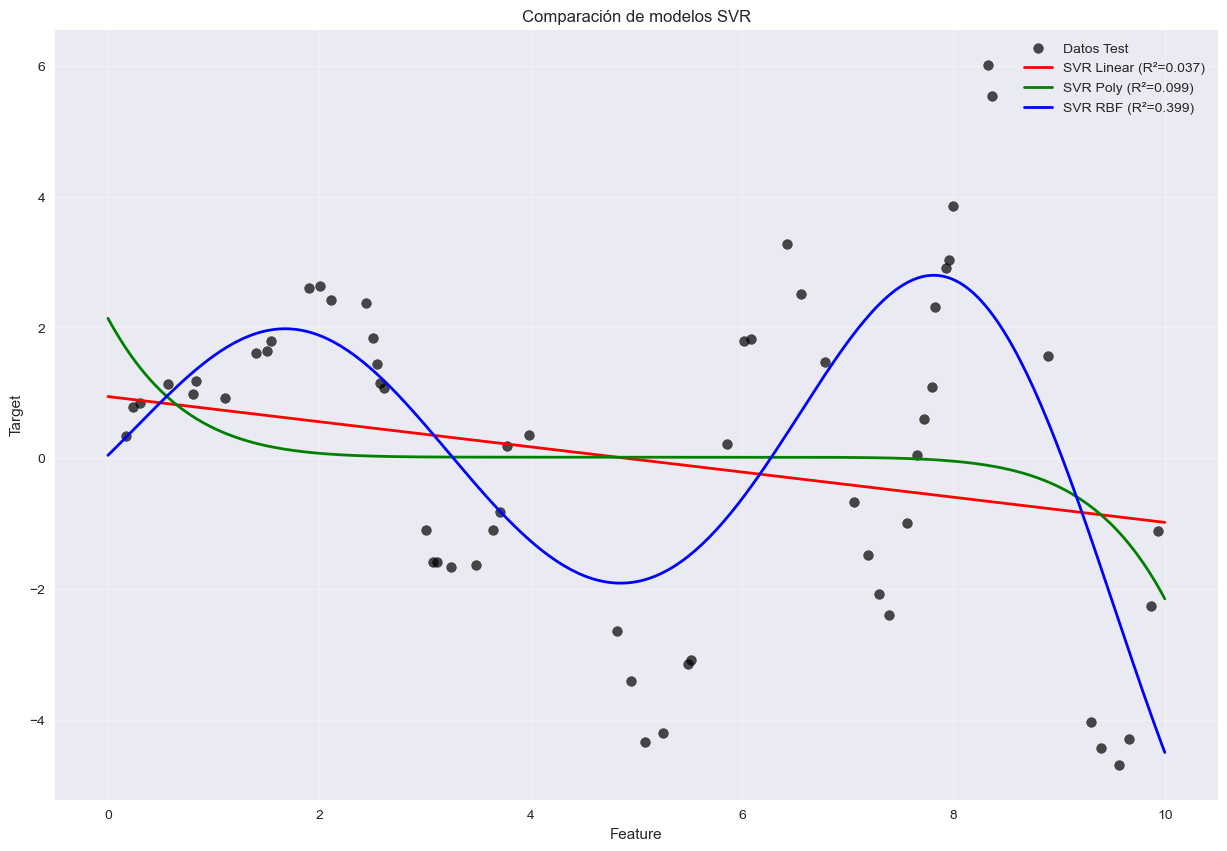

In [30]:
plt.figure(figsize = (15, 10))
plt.scatter(X_test, y_test, alpha=0.7, color='black', label='Datos Test', s=50)

plt.plot(X_plot, y_plot_linear, 'r-', linewidth=2, 
         label=f'SVR Linear (R²={r2_linear:.3f})')
plt.plot(X_plot, y_plot_poly, 'g-', linewidth=2, 
         label=f'SVR Poly (R²={r2_poly:.3f})')
plt.plot(X_plot, y_plot_rbf, 'b-', linewidth=2, 
         label=f'SVR RBF (R²={r2_rbf:.3f})')

plt.xlabel('Feature')
plt.ylabel('Target')
plt.title('Comparación de modelos SVR')
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()